# Ex - Linear Regression: Diamond Price Prediction

### Introduction:

This exercise brings together **everything we've practiced about Linear Regression**: loading a
real dataset, cleaning it, fixing outliers, encoding categories, normalizing, splitting into
train/test, writing **Gradient Descent from scratch**, and properly **evaluating** a regression
model (SST, SSR, SSE, R², MSE, RMSE, MAPE).

**Dataset:** the classic *diamonds* dataset — 53,940 real diamonds, each with its carat weight,
cut quality, color grade, clarity grade, physical dimensions, and price. Originally distributed
with the ggplot2 R package; this copy comes from the public
[seaborn-data](https://github.com/mwaskom/seaborn-data) mirror.

**Goal:** predict a diamond's `price` — first from just its `carat` weight (simple linear
regression), then from several columns together (multiple linear regression) — using an
optimizer you write yourself.

Work through the steps in order — later steps depend on variables created in earlier ones.

### Step 1. Import the necessary libraries
(`numpy`, `pandas`, `matplotlib`, and the scikit-learn pieces we'll need: `OrdinalEncoder`, `OneHotEncoder`, `MinMaxScaler`, `train_test_split`, `r2_score`, `mean_squared_error`, `mean_absolute_percentage_error`, `LinearRegression`)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression

np.random.seed(42)
print("Libraries loaded.")

Libraries loaded.


### Step 2. Load `diamonds.csv` into a variable called `diamonds`. Print its shape and the first 5 rows.

In [2]:
diamonds = pd.read_csv('diamonds.csv')
print(diamonds.shape)
diamonds.head()

(53940, 10)


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


### Step 3. Look at the data types and general info (`.info()`).

In [3]:
diamonds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  object 
 2   color    53940 non-null  object 
 3   clarity  53940 non-null  object 
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 4.1+ MB


### Step 4. Get summary statistics for every numeric column (`.describe()`).

In [4]:
diamonds.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


### Step 5. Check every column for missing values.

In [5]:
diamonds.isnull().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

### Step 6. Check for exact duplicate rows, then drop them. Print the shape before and after.

In [6]:
print("Before:", diamonds.shape)
diamonds = diamonds.drop_duplicates().reset_index(drop=True)
print("After: ", diamonds.shape)

Before: (53940, 10)
After:  (53794, 10)


### Step 7. Some diamonds have an impossible dimension of 0mm (`x`, `y`, or `z` equal to 0) — a real diamond can't have zero length, width, or depth. Find how many rows have this problem, then remove them.

In [7]:
bad_dimensions = (diamonds['x'] == 0) | (diamonds['y'] == 0) | (diamonds['z'] == 0)
print("Rows with an impossible 0mm dimension:", bad_dimensions.sum())

diamonds = diamonds[~bad_dimensions].reset_index(drop=True)
print("Shape after removing them:", diamonds.shape)

Rows with an impossible 0mm dimension: 19
Shape after removing them: (53775, 10)


### Step 8. Make a scatter plot of `carat` (x-axis) vs `price` (y-axis) to see the relationship.

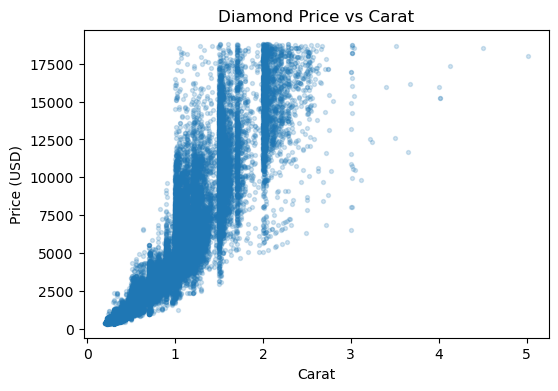

In [8]:
plt.figure(figsize=(6,4))
plt.scatter(diamonds['carat'], diamonds['price'], alpha=0.2, s=8)
plt.xlabel('Carat')
plt.ylabel('Price (USD)')
plt.title('Diamond Price vs Carat')
plt.show()

### Step 9. Detect price outliers using the IQR method — but compute the bounds **separately for each `cut` group**, not globally (a $15,000 Fair-cut diamond is far more unusual than a $15,000 Ideal-cut one). Print the lower/upper bound and outlier count for each cut.

In [9]:
def iqr_bounds(values):
    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

is_outlier = pd.Series(False, index=diamonds.index)

for cut_type, group_prices in diamonds.groupby('cut')['price']:
    lower, upper = iqr_bounds(group_prices)
    flagged = (group_prices < lower) | (group_prices > upper)
    is_outlier.loc[group_prices.index] = flagged
    print(f"{cut_type:<10} bounds=[{lower:>10,.0f}, {upper:>10,.0f}]  outliers={flagged.sum()}")

print("\nTotal outliers:", is_outlier.sum(), "out of", len(diamonds))

Fair       bounds=[    -2,655,      9,889]  outliers=144
Good       bounds=[    -4,666,     10,824]  outliers=323
Ideal      bounds=[    -4,832,     10,396]  outliers=1620
Premium    bounds=[    -6,820,     14,156]  outliers=750
Very Good  bounds=[    -5,777,     12,060]  outliers=730

Total outliers: 3567 out of 53775


### Step 10. Remove the outlier rows found in Step 9.

In [10]:
diamonds = diamonds[~is_outlier].reset_index(drop=True)
print("Shape after removing outliers:", diamonds.shape)

Shape after removing outliers: (50208, 10)


### Step 11. Encode `cut`, `color`, and `clarity` into numbers with `OrdinalEncoder`, respecting their real natural order:
- `cut`: Fair < Good < Very Good < Premium < Ideal
- `color`: J (worst) < I < H < G < F < E < D (best)
- `clarity`: I1 (worst) < SI2 < SI1 < VS2 < VS1 < VVS2 < VVS1 < IF (best)

Store the results in new columns `cut_enc`, `color_enc`, `clarity_enc`.

In [11]:
cut_order = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
color_order = ['J', 'I', 'H', 'G', 'F', 'E', 'D']
clarity_order = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']

diamonds['cut_enc'] = OrdinalEncoder(categories=[cut_order]).fit_transform(diamonds[['cut']]).ravel()
diamonds['color_enc'] = OrdinalEncoder(categories=[color_order]).fit_transform(diamonds[['color']]).ravel()
diamonds['clarity_enc'] = OrdinalEncoder(categories=[clarity_order]).fit_transform(diamonds[['clarity']]).ravel()

diamonds[['cut','cut_enc','color','color_enc','clarity','clarity_enc']].drop_duplicates().sort_values('cut_enc')

,cut,cut_enc,color,color_enc,clarity,clarity_enc
5336,Fair,0.0,E,5.0,VVS2,5.0
788,Fair,0.0,F,4.0,IF,7.0
777,Fair,0.0,F,4.0,VS1,4.0
771,Fair,0.0,D,6.0,VS2,3.0
19168,Fair,0.0,F,4.0,VVS1,6.0
...,...,...,...,...,...,...
234,Ideal,4.0,D,6.0,VS1,4.0
229,Ideal,4.0,F,4.0,IF,7.0
173,Ideal,4.0,E,5.0,VS1,4.0
1901,Ideal,4.0,H,2.0,I1,0.0


### Step 12. Just for comparison: use `OneHotEncoder` on the `cut` column instead, and print the result for the first 5 rows. In a markdown cell, explain in one sentence why we did NOT use this approach for `cut`, `color`, and `clarity` in our model.

In [12]:
onehot = OneHotEncoder(sparse_output=False)
onehot_example = onehot.fit_transform(diamonds[['cut']].head())
pd.DataFrame(onehot_example, columns=onehot.get_feature_names_out(['cut']))

# Answer: cut/color/clarity all have a natural quality ORDER, so numbering them 0,1,2,3...
# (ordinal encoding) preserves that order for the model. One-hot encoding would throw that
# order away and treat every category as equally "different" from every other.

,cut_Good,cut_Ideal,cut_Premium
0,0.0,1.0,0.0
1,0.0,0.0,1.0
2,1.0,0.0,0.0
3,0.0,0.0,1.0
4,1.0,0.0,0.0


### Step 13. Normalize `carat`, `depth`, `table`, `cut_enc`, `color_enc`, and `clarity_enc` into the range [0, 1] using `MinMaxScaler`. Store the normalized columns with a `_norm` suffix (e.g. `carat_norm`).

In [13]:
feature_cols = ['carat', 'depth', 'table', 'cut_enc', 'color_enc', 'clarity_enc']

scaler = MinMaxScaler()
normalized = scaler.fit_transform(diamonds[feature_cols])

for i, col in enumerate(feature_cols):
    diamonds[col + '_norm'] = normalized[:, i]

diamonds[[c + '_norm' for c in feature_cols]].describe().loc[['min','max']]

,carat_norm,depth_norm,table_norm,cut_enc_norm,color_enc_norm,clarity_enc_norm
min,0.0,0.0,0.0,0.0,0.0,0.0
max,1.0,1.0,1.0,1.0,1.0,1.0


### Step 14. Split the data into training (80%) and test (20%) sets using `train_test_split`. Use `random_state=1`. Call the results `train_df` and `test_df`.

In [14]:
norm_cols = [c + '_norm' for c in feature_cols]
model_df = diamonds[norm_cols + feature_cols + ['price']]

train_df, test_df = train_test_split(model_df, test_size=0.2, random_state=1)
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Training rows:", len(train_df))
print("Test rows:    ", len(test_df))

Training rows: 40166
Test rows:     10042


### Step 15. Write **Gradient Descent by hand** to fit a SIMPLE linear regression: `price = β0 + β1 × carat`. Use `carat_norm` as the input. Use a learning rate of 0.5 and run 3,000 rounds. Print the cost every 500 rounds.

In [15]:
x1 = train_df['carat_norm'].values
y = train_df['price'].values

b0 = 0.0
b1 = 0.0
learning_rate = 0.5
num_iterations = 3000
cost_history_simple = []

for i in range(num_iterations):
    predictions = b0 + b1 * x1
    mistakes = y - predictions

    slope_b0 = -2 * np.mean(mistakes)
    slope_b1 = -2 * np.mean(mistakes * x1)

    b0 = b0 - learning_rate * slope_b0
    b1 = b1 - learning_rate * slope_b1

    cost = np.mean(mistakes ** 2)
    cost_history_simple.append(cost)

    if i % 500 == 0:
        print(f"Round {i:4d}  b0={b0:10.2f}  b1={b1:10.2f}  cost={cost:,.0f}")

print("\nFinal (normalized-space):  b0 =", round(b0,3), " b1 =", round(b1,3))

Round    0  b0=   3174.06  b1=    884.83  cost=18,095,217
Round  500  b0=   -327.38  b1=  20249.13  cost=1,215,359
Round 1000  b0=   -328.40  b1=  20254.92  cost=1,215,359
Round 1500  b0=   -328.40  b1=  20254.93  cost=1,215,359
Round 2000  b0=   -328.40  b1=  20254.93  cost=1,215,359
Round 2500  b0=   -328.40  b1=  20254.93  cost=1,215,359

Final (normalized-space):  b0 = -328.399  b1 = 20254.927


### Step 16. Plot the cost history from Step 15 to confirm it flattens out (converges).

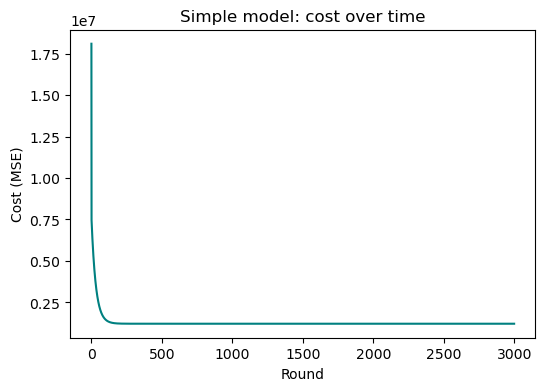

In [16]:
plt.figure(figsize=(6,4))
plt.plot(cost_history_simple, color='teal')
plt.xlabel('Round')
plt.ylabel('Cost (MSE)')
plt.title('Simple model: cost over time')
plt.show()

### Step 17. Convert `b0` and `b1` from Step 15 back to real, readable units (undo the normalization), and print the final equation.

In [17]:
carat_min, carat_max = scaler.data_min_[0], scaler.data_max_[0]

b1_real_simple = b1 / (carat_max - carat_min)
b0_real_simple = b0 - b1_real_simple * carat_min

print(f"Simple model equation:  price = {b0_real_simple:,.2f} + {b1_real_simple:,.2f} × carat")

Simple model equation:  price = -1,660.96 + 6,662.80 × carat


### Step 18. Write Gradient Descent by hand for the MULTIPLE linear regression: `price = β0 + β1·carat + β2·depth + β3·table + β4·cut + β5·color + β6·clarity`. All six slopes must be computed from the SAME mistakes and all seven numbers updated together, every round. Use a learning rate of 0.3 and run 20,000 rounds (this dataset is big — it needs more rounds than the simple model). Print the cost every 4,000 rounds.

In [18]:
feature_norm_cols = [c + '_norm' for c in feature_cols]
Xs = [train_df[col].values for col in feature_norm_cols]
y = train_df['price'].values

betas = [0.0] * (len(Xs) + 1)   # betas[0] is the intercept, betas[1:] line up with feature_cols
learning_rate = 0.3
num_iterations = 20000
cost_history_multi = []

for i in range(num_iterations):
    predictions = betas[0] + sum(betas[j+1] * Xs[j] for j in range(len(Xs)))
    mistakes = y - predictions

    slope_b0 = -2 * np.mean(mistakes)
    slopes = [slope_b0] + [-2 * np.mean(mistakes * Xs[j]) for j in range(len(Xs))]

    betas = [b - learning_rate * s for b, s in zip(betas, slopes)]

    cost = np.mean(mistakes ** 2)
    cost_history_multi.append(cost)

    if i % 4000 == 0:
        print(f"Round {i:5d}  cost={cost:,.0f}")

print("\nFinal (normalized-space) betas:", [round(b,3) for b in betas])

Round     0  cost=18,095,217
Round  4000  cost=760,300
Round  8000  cost=760,298
Round 12000  cost=760,298
Round 16000  cost=760,298

Final (normalized-space) betas: [-2324.52, 23163.359, -1241.286, -286.508, 361.433, 1377.524, 2733.076]


### Step 19. Plot the cost history from Step 18.

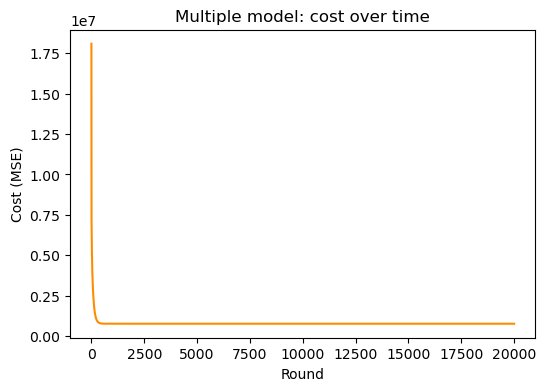

In [19]:
plt.figure(figsize=(6,4))
plt.plot(cost_history_multi, color='darkorange')
plt.xlabel('Round')
plt.ylabel('Cost (MSE)')
plt.title('Multiple model: cost over time')
plt.show()

### Step 20. Convert the Step 18 betas back to real units and print the full equation.

In [20]:
mins = scaler.data_min_
maxs = scaler.data_max_

betas_real = [betas[j+1] / (maxs[j] - mins[j]) for j in range(len(feature_cols))]
intercept_real = betas[0] - sum(betas_real[j] * mins[j] for j in range(len(feature_cols)))

equation_terms = " + ".join(f"{betas_real[j]:,.2f}×{feature_cols[j]}" for j in range(len(feature_cols)))
print(f"Multiple model equation:  price = {intercept_real:,.2f} + {equation_terms}")

Multiple model equation:  price = -2,023.56 + 7,619.53×carat + -34.48×depth + -7.96×table + 90.36×cut_enc + 229.59×color_enc + 390.44×clarity_enc


### 📎 Formula reference — you'll need these for the evaluation steps

For any set of predictions, with `n` = number of rows, `actual` = real values, `predicted` = your
model's guesses, and `mean(actual)` = the average of the real values:

| Name | Formula | Plain-English meaning |
|---|---|---|
| **SST** (Total Sum of Squares) | `Σ (actual − mean(actual))²` | How spread out the real values are, ignoring the model entirely |
| **SSE** (Sum of Squared Errors) | `Σ (actual − predicted)²` | How wrong the model's predictions are (a.k.a. residual sum of squares) |
| **SSR** (Regression Sum of Squares) | `Σ (predicted − mean(actual))²` | How much of that spread the model explains |
| **Identity** | `SST = SSR + SSE` | Total spread = explained spread + unexplained spread |
| **R²** | `1 − SSE/SST` (equivalently `SSR/SST`) | Fraction of the spread the model explains (1.0 = perfect) |
| **MSE** | `SSE / n` | Average squared mistake |
| **RMSE** | `√MSE` | Average mistake, back in the SAME units as price ($) |
| **MAPE** | `mean(\|actual − predicted\| / \|actual\|) × 100` | Average mistake as a percentage of the real value |

⚠️ The `SST = SSR + SSE` identity holds **exactly** on the data a model was fit on (the training
set) — that's a mathematical guarantee of least-squares fitting. It's usually only *approximately*
true on a held-out test set. Keep that in mind for Step 21 vs. Step 22 below.

### Step 21. On the TRAINING set, compute SST, SSR, and SSE for the multiple model, and confirm `SST ≈ SSR + SSE` (this identity holds almost exactly here — it's a guarantee of the fitting process, on the data the model was actually fit to).

In [21]:
predictions_train = betas[0] + sum(betas[j+1] * Xs[j] for j in range(len(Xs)))

sst_train = np.sum((y - y.mean()) ** 2)
sse_train = np.sum((y - predictions_train) ** 2)
ssr_train = np.sum((predictions_train - y.mean()) ** 2)

print(f"SST = {sst_train:,.0f}")
print(f"SSR = {ssr_train:,.0f}")
print(f"SSE = {sse_train:,.0f}")
print(f"SSR + SSE = {ssr_train + sse_train:,.0f}")
print("SST ≈ SSR + SSE ?", np.isclose(sst_train, ssr_train + sse_train, rtol=1e-6))

SST = 322,154,065,492
SSR = 291,615,923,720
SSE = 30,538,132,081
SSR + SSE = 322,154,055,801
SST ≈ SSR + SSE ? True


### Step 22. On the TEST set, compute R², MSE, RMSE, and MAPE for BOTH the simple model (Step 17) and the multiple model (Step 20). Print them side by side so you can compare.

In [22]:
def evaluate(y_true, y_pred, label):
    sse = np.sum((y_true - y_pred) ** 2)
    sst = np.sum((y_true - y_true.mean()) ** 2)
    r2 = 1 - sse / sst
    mse = sse / len(y_true)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f"{label:<20} R2={r2:.4f}   MSE={mse:>12,.0f}   RMSE={rmse:>8,.2f}   MAPE={mape:>6.2f}%")
    return r2, mse, rmse, mape

y_test = test_df['price'].values

x1_test = test_df['carat_norm'].values
predictions_simple_test = b0 + b1 * x1_test
evaluate(y_test, predictions_simple_test, "Simple (carat)")

Xt = [test_df[col].values for col in feature_norm_cols]
predictions_multi_test = betas[0] + sum(betas[j+1] * Xt[j] for j in range(len(Xt)))
evaluate(y_test, predictions_multi_test, "Multiple (6 cols)")

Simple (carat)       R2=0.8490   MSE=   1,146,896   RMSE=1,070.93   MAPE= 28.17%
Multiple (6 cols)    R2=0.9063   MSE=     711,986   RMSE=  843.79   MAPE= 35.90%


(0.9062869434530507, 711986.4452178384, 843.7928923721972, 35.90227535837763)

### Step 23. Double-check your gradient descent against scikit-learn's `LinearRegression`, fit on the exact same training rows, for BOTH models.

In [23]:
sklearn_simple = LinearRegression().fit(train_df[['carat']], train_df['price'])
print("Simple model:")
print(f"  Our gradient descent :  price = {b0_real_simple:,.2f} + {b1_real_simple:,.2f} × carat")
print(f"  scikit-learn shortcut:  price = {sklearn_simple.intercept_:,.2f} + {sklearn_simple.coef_[0]:,.2f} × carat")

sklearn_multi = LinearRegression().fit(train_df[feature_cols], train_df['price'])
print("\nMultiple model:")
print("  Our gradient descent :", {c: round(b,2) for c,b in zip(feature_cols, betas_real)}, " intercept:", round(intercept_real,2))
print("  scikit-learn shortcut:", {c: round(b,2) for c,b in zip(feature_cols, sklearn_multi.coef_)}, " intercept:", round(sklearn_multi.intercept_,2))

Simple model:
  Our gradient descent :  price = -1,660.96 + 6,662.80 × carat
  scikit-learn shortcut:  price = -1,660.96 + 6,662.80 × carat

Multiple model:
  Our gradient descent : {'carat': 7619.53, 'depth': -34.48, 'table': -7.96, 'cut_enc': 90.36, 'color_enc': 229.59, 'clarity_enc': 390.44}  intercept: -2023.56
  scikit-learn shortcut: {'carat': 7619.53, 'depth': -34.48, 'table': -7.96, 'cut_enc': 90.36, 'color_enc': 229.59, 'clarity_enc': 390.44}  intercept: -2023.72


### Step 24. Reflection (answer in this markdown cell, no code needed): Which model performed better on the test set, and by how much? Does adding more columns always improve a model? What do you think would happen if you also added `x`, `y`, and `z` (the physical dimensions) to the multiple model, given how closely they relate to `carat`?